# ML Uncertainty Workshop
*Liina, Tik, Yonas & Kajetan*

As the old saying goes, every man should plant a **tree**, build a house and raise a son. Today, regardless of your gender, you will plant not just one tree but entire (random) **forest**, laying firm mathematical foundations for less uncertain future of your children.

More seriously, you will learn how to quantify the uncertainty of your Random Forest (RF) predictions. Remember that for a given set of covariates (input), Random Forest returns a single number - a prediction of the target variable.  **We want to answer the question - *how confident are we about this prediction?*, but how on Earth can we do it based on a single number?**

Well, we  leverage the inner structure of the forest, which consists of multiple trees. But if you think it is enough to just calculate variance of predictions from different trees, we have to surprise you. **Trees are often correlated, and variance across trees grossly underestimates the uncertainty**. We need something better, the **Quantile Regression Forest**, or QRF for short, developed by Nicolai Meinshausen, a statistician from ETH Zurich [(Meinshausen, 2006)](https://www.jmlr.org/papers/volume7/meinshausen06a/meinshausen06a.pdf). It estimates **prediction intervals**.

Today, we will:
1. Start with a synthetic 1D example - allowing you to add different types of noise and see how RF predictions and their uncertainty change. We will compare estimates from different methods - QRF, but also confidence intervals from **Infinitesimal Jackknife** and a simple "naive" calculation of variance across trees.
2. Take our favourite dataset (Estonian WQ from Holger's 2022 paper) and train the Quantile Regression Forest on it the real-world data, not just to get the predictions of Total Nitrogen concentrations, but also to quantify their uncertainty.

For QRF in Python, we will use [quantile-forest](https://zillow.github.io/quantile-forest/index.html) as its Python implementation. We will compare it to [foresci](https://contrib.scikit-learn.org/forest-confidence-interval/index.html), a Python library that implements a clever algorithm by [Wager et al. (2016)](https://jmlr.org/papers/volume15/wager14a/wager14a.pdf) that enables efficient and effective estimation of **confidence intervals** of Random Forest predictions. 

Note the **subtle but important difference** between a *confidence interval* (uncertainty about the mean prediction) and a *prediction interval* (uncertainty about where a new observation will fall).

We hope you'll have fun and learn something new!






### Notebook set-up

#### Import libraries

In [ ]:
# Uncomment the following line to install libraries unavailable in Colab 
!pip install -q forestci==0.6 quantile-forest ipywidgets
# Note, the forestci==0.6 version is crucial. 

In [ ]:
import forestci as fci
import geopandas as gpd
from ipywidgets import interact, IntSlider, FloatSlider
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV  
from sklearn.ensemble import RandomForestRegressor
# from sklearn.inspection import partial_dependence
from sklearn.metrics import r2_score, mean_squared_error
from quantile_forest import RandomForestQuantileRegressor

# Ignore some warnings that show up when pushing some ML libraries to their limits
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, module='forestci')
warnings.filterwarnings('ignore', category=RuntimeWarning, message='overflow encountered')

# Set a random seed for reproducibility 
SEED = 42
# Set global numpy seed (affects np.random.*)
np.random.seed(SEED)
# For explicit control, use a RandomState and pass it everywhere it's accepted
rng = np.random.RandomState(SEED)

# Create data directory (if not existing already) to keep everything tidy
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

#### Download data

In [ ]:
base_url = "https://github.com/kmch/seminar-ml-uncertainty-2026/raw/main/data/"
files = [
    "agile2024_tn_mean_obs_sites.gpkg",
    "estonia_outline.shp",
    "estonia_outline.shx",
    "estonia_outline.dbf",
    "estonia_outline.prj",
    "estonia_outline.cpg",
]

for fname in files:
    path = f"{data_dir}/{fname}"
    if not os.path.exists(path):
        from urllib.request import urlretrieve
        urlretrieve(base_url + fname, path)

#### Load helper functions

In [3]:
figsize = (10,6) # size of the figure
bounds = 0, 100 # bounds of the covariate
xlim = bounds
ylim = -20, 20
x_axis = np.linspace(*bounds, 10000) # covariate values for which we want to make predictions

def skewed_uniform(low, high, size, skew):
    """
    Generate a skewed uniform distribution.

    Parameters
    ----------
    low: float
      lower bound of the distribution
    high: float
      upper bound of the distribution
    size: int
      number of samples to generate
    skew: float
      exponent controlling shape
      skew = 1  →  uniform
      skew > 1  →  skewed toward low
      skew < 1  →  skewed toward high
    """
    u = np.random.uniform(0, 1, size)
    return low + (high - low) * np.power(u, 1 / skew)

def generate_covar(n_samples: int, sample_skew: float) -> np.ndarray:
  """
  Generate a skewed uniform distribution of covariate values 
  between pre-defined bounds.

  Parameters
  ----------
  n_samples: int
    number of samples to generate
  sample_skew: float
    exponent controlling shape
      skew = 1  →  uniform
      skew > 1  →  skewed toward low
      skew < 1  →  skewed toward high
  """
  x = skewed_uniform(*bounds, n_samples, sample_skew)
  return x

def plot_covar(x):
  plt.plot(x, '.')
  plt.xlabel('sample')
  plt.ylabel('covariate $x$')
  plt.ylim(*bounds)
  return plt.gca()

def f(x):
  """ 
  This is the function that we want to predict. In our case, it is a simple sine function.
  It takes a single covariate value $x$ and returns a single target value $y$.
  It is our "ground truth" that we want to recover using our model.
  """
  amplitude = 10
  xmin, xmax = bounds
  frequency = 2 * np.pi / (xmax - xmin)
  phase = 0
  return amplitude * np.sin(frequency * x + phase)

def generate_noise(x, sigma_x_min, sigma_x_max):
  """
  Generate noise for a given covariate value $x$.
  """
  xmin, xmax = bounds
  sigma = lambda x: sigma_x_min + (x - xmin) * (sigma_x_max - sigma_x_min) / (xmax - xmin)
  noise = np.random.normal(0, sigma(x))
  return noise

def generate_data(n_samples, sample_skew, noise_level_left, noise_level_right):
    x = generate_covar(n_samples, sample_skew)
    y = f(x) + generate_noise(x, noise_level_left, noise_level_right)
    return x, y

def plot_results(model, mean_predicted, ci_naive=None, ci_jackknife=None, median_qrf=None, ci_qrf=None, show_metrics=True):
    fig, ax = plt.subplots(figsize=figsize)
    
    # Line plots
    ax.plot(x_axis, f(x_axis), '-', color='limegreen', label='Ground truth', zorder=1)
    ax.plot(x_axis, mean_predicted, '-', color='k', lw=1, label='Mean RF prediction')
    # ax.fill_between(x_axis, *ci_naive, alpha=0.3, color='gray', label='95% CI (naive)')
    naive_kwargs = dict(color='k', lw=1)
    if ci_naive is not None:
      ax.plot(x_axis, ci_naive[0], '--', **naive_kwargs, label='95% CI (naive)')
      ax.plot(x_axis, ci_naive[1], '--', **naive_kwargs)
    # if median_qrf is not None:
    #   ax.plot(x_axis, median_qrf, '-', color='red', lw=1, label='Median QRF prediction')
    if ci_jackknife is not None:
      ax.fill_between(x_axis, *ci_jackknife, alpha=0.25, color='gray', label='95% CI (jackknife)')
    if ci_qrf is not None and ci_qrf[0] is not None:
      ax.fill_between(x_axis, *ci_qrf, alpha=0.25, color='lightblue', label='95% PI (QRF)')

    # Scatter plots
    sc_kwargs = dict(marker='.', alpha=1, s=100)
    ax.scatter(model.X_train, model.y_train, color='b', **sc_kwargs, label='Training data')
    ax.scatter(model.X_test, model.y_test,   color='r', **sc_kwargs, label='Test data')
    
    # Axes formatting
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(*bounds)
    ax.set_ylim(-20, 20)
    ax.legend(loc='lower left')
    
    # Metrics
    if show_metrics:
        lines = [f'R^2_train = {model.r2_train:.3f}', f'R^2_test = {model.r2_test:.3f}']
        if model.r2_oob is not None:
            lines.append(f'R^2_oob = {model.r2_oob:.3f}')
        textstr = '\n'.join(lines)
        ax.text(0.81, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict( facecolor='w', alpha=0.5))
    return fig, ax



#### Load ML modelling framework

In [4]:
class Model:
  """
  This implements our entire Machine Learning workflow.
  It allows us to train a model, make predictions and compute uncertainty intervals.
  It works for both Random Forests and Quantile Regression Forests.
  It also allows us to compute the uncertainty intervals in a rather naive way (mean prediction from all trees) and using the jackknife method.
  """
  def __init__(self, model_type='rf', n_trees=100):
    self._init_hyperparams(n_trees)
    self._init_regressor(model_type, self.hyperparams)
  
  def _init_hyperparams(self, n_trees):
    self.hyperparams = dict(
      n_estimators=n_trees,   # Number of trees in the forest
      bootstrap=True,         # Whether to use bootstrap samples when building trees
      oob_score=True,         # Whether to use out-of-bag samples to estimate the generalization accuracy
      max_depth=3,            # Limit the maximum depth of each tree to avoid overfitting
      min_samples_leaf=4,     # Minimum number of samples required to be at a leaf node
      min_samples_split=4,    # Minimum number of samples required to split an internal node
    )
  def _init_regressor(self, model_type, hyperparams):
    self.model_type = model_type
    if model_type == 'rf':
      self.info = 'Random Forest'
      self.regressor = RandomForestRegressor(**hyperparams)
    elif model_type == 'qrf':
      self.info = 'Quantile Regression Forest'
      self.regressor = RandomForestQuantileRegressor(**hyperparams)
    else:
      raise ValueError(f"Invalid model type: {model_type}")

  def split_and_train(self, x=None, y=None, X_train=None, X_test=None, y_train=None, y_test=None):
    if X_train is not None:
      self.X_train, self.X_test = X_train, X_test
      self.y_train, self.y_test = y_train, y_test
    else:
      X = np.atleast_2d(x).T
      X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=SEED)
      self.X_train, self.X_test = X_train, X_test
      self.y_train, self.y_test = y_train, y_test
    self.regressor.fit(self.X_train, self.y_train)
    self.r2_train = r2_score(self.y_train, self.regressor.predict(self.X_train))
    self.r2_test = r2_score(self.y_test, self.regressor.predict(self.X_test))
    self.r2_oob = getattr(self.regressor, 'oob_score_', None)

  def predict(self, x):
    return self.regressor.predict(np.atleast_2d(x).T)

  def predict_confidence_interval_naive(self, x, lower_quantile=2.5, upper_quantile=97.5):
    """2.5th and 97.5th percentiles over trees (RF only)."""
    if self.model_type != 'rf':
      return None, None
    X = np.atleast_2d(x).T
    tree_preds = np.array([tree.predict(X) for tree in self.regressor.estimators_])
    lower = np.percentile(tree_preds, lower_quantile, axis=0)
    upper = np.percentile(tree_preds, upper_quantile, axis=0)
    return lower, upper

  def predict_confidence_interval_jackknife(self, x):
    """Infinitesimal jackknife 95% CI via forestci (RF only)."""
    if self.model_type != 'rf':
      return None, None
    X = np.atleast_2d(x).T
    variance = fci.random_forest_error(self.regressor, self.X_train, X)
    std = np.sqrt(variance)
    mean_pred = self.regressor.predict(X)
    lower = mean_pred - 1.96 * std
    upper = mean_pred + 1.96 * std
    return lower, upper

  def predict_prediction_interval_qrf(self, x):
    """95% prediction interval from quantile forest (QRF only)."""
    if self.model_type != 'qrf':
      return None, None
    X = np.atleast_2d(x).T
    pred = self.regressor.predict(X, quantiles=[0.025, .5, 0.975])
    lower = pred[:, 0]
    median = pred[:, 1]
    upper = pred[:, 2]
    return median, (lower, upper)

In [5]:
def run_analysis(n_samples, sample_skew, noise_level_left, noise_level_right, n_trees):
    x, y = generate_data(n_samples, sample_skew, noise_level_left, noise_level_right)
    rf = Model(model_type='rf', n_trees=n_trees)
    rf.split_and_train(x, y)
    qrf = Model(model_type='qrf', n_trees=n_trees)
    qrf.split_and_train(X_train=rf.X_train, X_test=rf.X_test, y_train=rf.y_train, y_test=rf.y_test)
    mean_predicted = rf.predict(x_axis)
    ci_naive = rf.predict_confidence_interval_naive(x_axis)
    ci_jackknife = rf.predict_confidence_interval_jackknife(x_axis)
    median_qrf, ci_qrf = qrf.predict_prediction_interval_qrf(x_axis)
    fig, ax = plot_results(rf, mean_predicted, ci_naive, ci_jackknife=ci_jackknife, median_qrf=median_qrf, ci_qrf=ci_qrf)

## Intro to ML uncertainty

A Machine Learning model is simply a function that takes covariates (also known as features) as input and outputs a prediction of a target variable.

In environmental science, the covariates are usually environmental parameters — proportion of arable land, average temperature, precipitation, livestock density, etc. — and the target is the environmental response we want to predict, such as the concentration of total nitrogen (TN) at a river outlet. Covariates are denoted $X$ (or $x$ for a specific value); the target is denoted $y$.

The observed data with which we train our model is a collection of covariate-target pairs $(x_i, y_i)$. In general, we use multiple covariates. However, in the simple example that follows, the covariate is a single variable $x$ and the target is:

$$y = f(x) + \epsilon$$

where $f$ is the true underlying function and $\epsilon$ is a noise term.

### A motivating example: predicting Total Nitrogen


Imagine you are an environmental scientist aiming to predict Total Nitrogen (TN) concentration in rivers based on environmental covariates.

Let's assume a hypothetical scenario where you have access to _every single covariate_ that affects TN: the exact acreage of arable land, specific crop types, precise livestock and human populations, daily climate data, exact fertilizer application schedules, the exact number of illegal sewage outlets, the efficiency of every water treatment plant, you name it. There is not a single phenomenon affecting TN that you don't have data for!

Even with all this data, you still need to understand _how_ these variables combine to dictate TN concentration. Normally, you might use a deterministic physical model (like a hydrological routing model). But in this scenario, we will use machine learning to build an empirical model from the data.

You sample water at various river network points. Your TN measurements are your target variable, $y_i$. For each $y_i$, you have a perfect vector of covariates, $x_i$.

So far so good — but what happens when our measurements or our knowledge of the system aren't perfect?

### Sources of uncertainty

In any modelling exercise, predictions are uncertain. It is useful to distinguish two fundamental types of uncertainty:

- **data uncertainty** (a.k.a. aleatoric) — randomness that our model cannot capture, no matter how much training data we collect. It includes measurement noise, natural stochasticity, and — in practice — any variability that the available covariates cannot explain.
- **model uncertainty** (a.k.a. epistemic) — uncertainty that arises from our limited knowledge and finite data. In principle, it can be reduced by collecting more data, adding better covariates, or using a more flexible model.

#### Aleatoric uncertainty: measurement error and natural variability

As a rigorous scientist, you revisit the exact same sampling sites multiple times under the exact same environmental conditions (meaning $x$ is identical). You expect the exact same $y$ value. But you don't get it.

Why? Measurement error. Perhaps a **beaver** disturbed the riverbed and you accidentally sampled suspended sediment instead of clear water. Or perhaps the lab equipment calibration drifted during the persulfate digestion process used to measure TN.

Even with perfect covariate knowledge, a single $x$ gives you a _spread_ of $y$ values. From the model's perspective, this spread is **data uncertainty** — the model sees identical inputs producing different outputs and has no way to resolve the difference.

#### Model uncertainty: too scarce data points, incomplete set covariates, etc. 

Now, let's drop the assumption of perfect information. In reality, you are ignorant of many phenomena that affect TN. Let's say one of them are illegal sewage spills. This becomes a "hidden variable." Because your knowledge is incomplete, your identical $x$ values (based only on the covariates you _do_ have) will map to considerably varying $y$ values. The spread of values you get for a given $x$ is now wider as it adds a new source of uncertainty to the previous one.

This additional spread is **model uncertainty** — it arises from our incomplete knowledge of the system. If we could measure and include the hidden variable, this portion of the uncertainty would shrink. Note, however, that the model cannot tell whether two $y$ values differ because of measurement noise or a missing covariate — both look the same from its point of view. The problem of disentangling model and data uncertainties in most real-world scenarios is very challenging if not impossible.

In practice, we have uncertainty coming from all sources combined: measurement errors, natural variability, and missing information. 

### The solution: Quantile Regression Forests (QRF)

To estimate the actual distribution of the data, we use a Quantile Regression Forest. It is an elegant adjustment to standard RFs that quantifies the conditional distribution, $F(Y \mid X=x)$.

Instead of having each tree calculate the _mean_ of the $y$ values in its terminal leaf, QRF keeps track of _all_ the original training data points that fall into that leaf.

When you make a new prediction for a specific environment ($x_{\text{new}}$):

1. The QRF drops $x_{\text{new}}$ down every tree.
2. It looks at the terminal leaves $x_{\text{new}}$ lands in.
3. It aggregates all the original training $y$ values that share those leaves, assigning them weights based on how frequently they end up in the same leaf as $x_{\text{new}}$.
4. It builds an empirical distribution from these weighted points.

From this distribution, you can extract percentiles (like the 5th and 95th) to see the actual, expected spread of TN in the real world. QRF captures both aleatoric and epistemic uncertainty combined.

### How QRF works: a minimal example

Let's use **6 training points**, **2 trees**, and predict for a **new point x\* = 2.5**.

#### Training Data

```
Point:  P1   P2   P3   P4   P5   P6
X:       1    2    3    7    8    9
Y:       2    4    3    8   10    9
```

On a number line:

```
X-axis:
|----P1--P2--P3-----------P4--P5--P6----|
0    1   2   3   4   5   6   7   8   9  10

x* = 2.5 is here:
|----P1--P2--x*-P3---------P4--P5--P6---|
```

---

#### Tree 1 (splits at X < 5)

```
            [all points]
            X < 5?
           /         \
        YES            NO
         |              |
   [P1, P2, P3]    [P4, P5, P6]
    Y: 2, 4, 3      Y: 8, 10, 9
```

x\* = 2.5 goes **LEFT** and lands in leaf with **P1, P2, P3**

```
Leaf size = 3
Each co-leaf-member gets weight: 1/3
```

---

#### Tree 2 (splits at X < 2.5)

```
            [all points]
            X < 2.5?
           /           \
        YES              NO
         |                |
     [P1, P2]      [P3, P4, P5, P6]
      Y: 2, 4        Y: 3, 8, 10, 9
```

x\* = 2.5 goes **RIGHT** and lands in leaf with **P3, P4, P5, P6**

```
Leaf size = 4
Each co-leaf-member gets weight: 1/4
```

---

#### Computing the Weights

For each training point, ask: **"How often did it share a leaf with x\*?"**

```
         Tree 1          Tree 2
         co-leaf?        co-leaf?       Raw contribution

P1       YES (1/3)       NO  (0)        (1/3 + 0)  / 2  =  4/24
P2       YES (1/3)       NO  (0)        (1/3 + 0)  / 2  =  4/24
P3       YES (1/3)       YES (1/4)      (1/3 + 1/4)/ 2  =  7/24
P4       NO  (0)         YES (1/4)      (0   + 1/4)/ 2  =  3/24
P5       NO  (0)         YES (1/4)      (0   + 1/4)/ 2  =  3/24
P6       NO  (0)         YES (1/4)      (0   + 1/4)/ 2  =  3/24
                                                    Sum = 24/24 = 1
```

Final weights (as fractions of 24):

```
P1  ████░░░░░░░░  4/24  (Y=2)
P2  ████░░░░░░░░  4/24  (Y=4)
P3  ███████░░░░░  7/24  (Y=3)   ← appears in BOTH trees' neighborhoods
P4  ███░░░░░░░░░  3/24  (Y=8)
P5  ███░░░░░░░░░  3/24  (Y=10)
P6  ███░░░░░░░░░  3/24  (Y=9)
```

Notice what happened: **P3 gets the most weight** because it was a neighbor of x\* in both trees. P4/P5/P6 got pulled in by Tree 2 even though they're far away on the X-axis — this is a "mistake" caused by having only 2 trees. With more trees and deeper splits, far-away points would rarely share a leaf with x\*.

---

#### Building the Prediction Interval

Now we have a **weighted empirical distribution** of Y:

```
Y value:   2     3     4     8     9    10
Weight:   4/24  7/24  4/24  3/24  3/24  3/24

Cumulative:
          4/24  11/24  15/24  18/24  21/24  24/24
          17%   46%    63%    75%    88%   100%
```

Drawn as a weighted CDF:

```
100% |                                      ●
 88% |                               ●
 75% |                        ●
 63% |               ●
 46% |       ●
 17% |  ●
     |__|___|___|___|___|___|___
        2   3   4   5   6   7   8   9  10
                              Y value
```

From this you can read off any quantile:

- **Median (50th percentile):** ~Y = 3.4 (between P3 and P2)
- **80% prediction interval:** roughly Y ∈ [2, 9]
- **The mean prediction:** 2×(4/24) + 3×(7/24) + 4×(4/24) + 8×(3/24) + 9×(3/24) + 10×(3/24) ≈ **5.0**

---

#### The Key Intuition

> The forest doesn't predict a number. It points at training points and says _"these are your neighbors at x\*."_ The spread of their Y values **is** your uncertainty.

With real forests (500+ trees, deeper splits), the neighborhood becomes tight and meaningful — only genuinely similar training points accumulate high weights. The width of the resulting Y distribution then honestly reflects how much Y varies among points truly similar to x\*.

### In practice: Confidence Intervals vs. Prediction Intervals

When doing this in R or Python, you will encounter two ways to quantify your uncertainty. It is vital to know the difference:

- **Confidence Intervals (CIs) via `forestci`:** This targets the model's uncertainty about the _mean_. It answers: _"If I collected different training data and rebuilt this model, how much would my average prediction change?"_ This captures **epistemic uncertainty**.
- **Prediction Intervals (PIs) via `quantile-forest`:** This targets where a _new, individual observation_ will fall. It includes both model uncertainty AND irreducible noise. This captures **epistemic + aleatoric uncertainty**.

Formally, the total variance for a new observation is:

$$\text{Var}(Y \mid X=x) = \underbrace{\text{Var}(\hat f(x))}_{\text{mean estimation (CI)}} + \underbrace{\sigma^2(x)}_{\text{irreducible noise}}$$

## Simple 1D example

Here we will use a simple 1D example to illustrate the concept of uncertainty in machine learning. We will use a simple sine function and add some noise to it. We will then fit a Random Forest to the data and compute the uncertainty of the predictions using the following methods:

- **Naive confidence interval** — taking mean predictions from all the RF trees and using the 2.5th and 97.5th percentiles
- **Jackknife confidence interval** — via the `forestci` library
- **Quantile Regression Forest prediction interval** — via the `quantile-forest` library

The takeaway from this example is that the uncertainty of the predictions is **not constant** and depends on the input. The most realistic quantification of uncertainty is provided by QRF, which can compute a prediction interval across the entire range of the data.



### The Question

Before we dive into the mechanics of how to prepare such data yourself, let's start with a concrete example. Below is a dataset generated from some unknown process. Have a look at the data and then at the Random Forest's prediction.

In [23]:
n_samples = 200
sample_skew = 1
noise_level_left = 0
noise_level_right = 5
n_trees = 100

x_q, y_q = generate_data(n_samples, sample_skew, noise_level_left, noise_level_right)
rf_q = Model(model_type='rf', n_trees=n_trees)
rf_q.split_and_train(x_q, y_q)
mean_predicted_q = rf_q.predict(x_axis)

Here is the plot of the observed data:

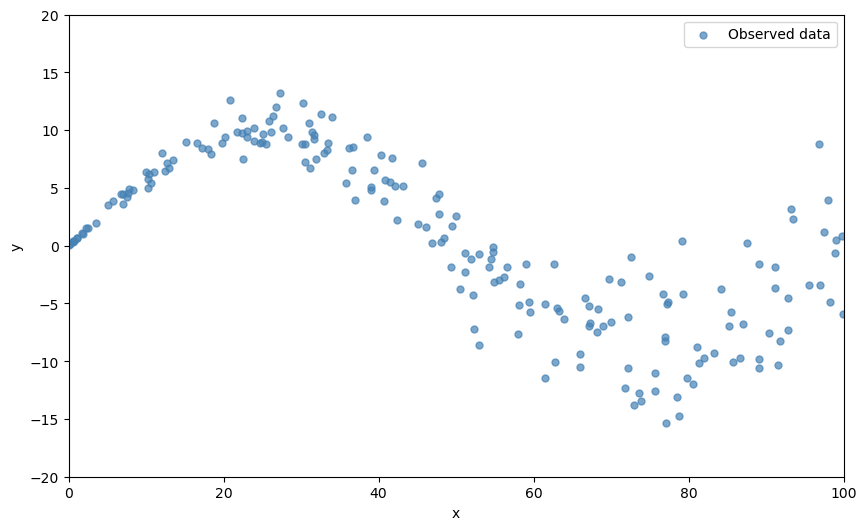

In [26]:
fig, ax = plt.subplots(figsize=figsize)
ax.scatter(x_q, y_q, marker='.', s=100, alpha=0.7, color='steelblue', label='Observed data')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(*bounds)
ax.set_ylim(*ylim)
ax.legend()
plt.show()

And here is the prediction from a Random Forest model (mean of all trees):

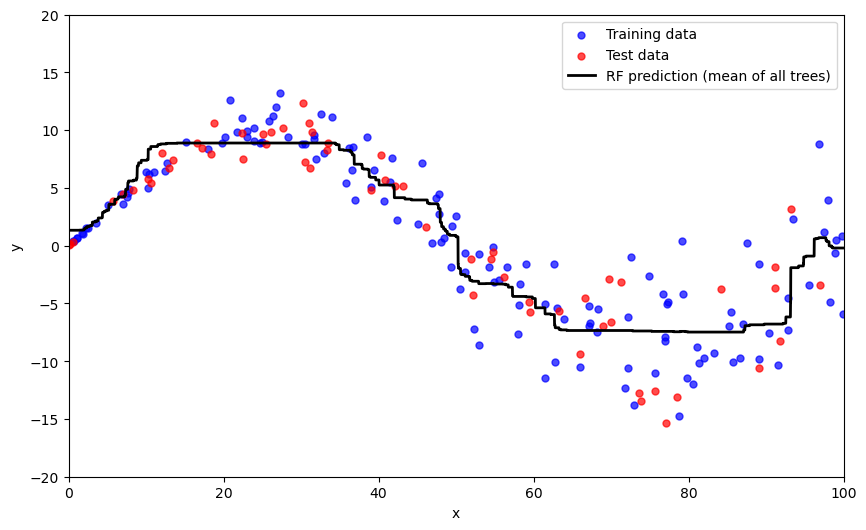

In [ ]:
fig, ax = plt.subplots(figsize=figsize)
ax.scatter(rf_q.X_train, rf_q.y_train, marker='.', s=100, alpha=0.7, color='blue', label='Training data')
ax.scatter(rf_q.X_test, rf_q.y_test, marker='.', s=100, alpha=0.7, color='red', label='Test data')
ax.plot(x_axis, mean_predicted_q, '-', color='k', lw=2, label='RF prediction (mean of all trees)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(*bounds)
ax.set_ylim(*ylim)
ax.legend()
plt.show()

#### **Think about the following questions**

- How confident are you in these predictions?
- Where is the model most reliable? Where is it least reliable?
- What might the true underlying function look like?
- How would you quantify the uncertainty of the predictions?

You will find out in the following subsections!

### Define a physical model

Let's start by defining the physical model that fully describes how the target variable depends on the covariate. It is the ground truth that we want to recover using our model. In our case, it is a simple sine function.

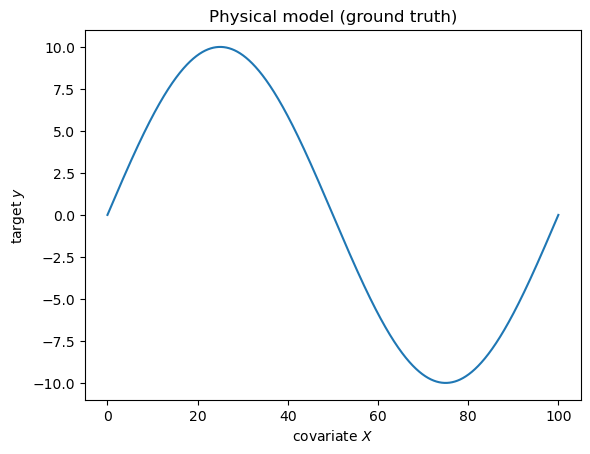

In [9]:
# Let's plot it over the entire range of the covariate.
_ = plt.plot(x_axis, f(x_axis), '-')
plt.xlabel('covariate $X$')
plt.ylabel('target $y$')
plt.title('Physical model (ground truth)')
plt.show()


### Generate covariate values

We generate a skewed uniform distribution of covariate values.

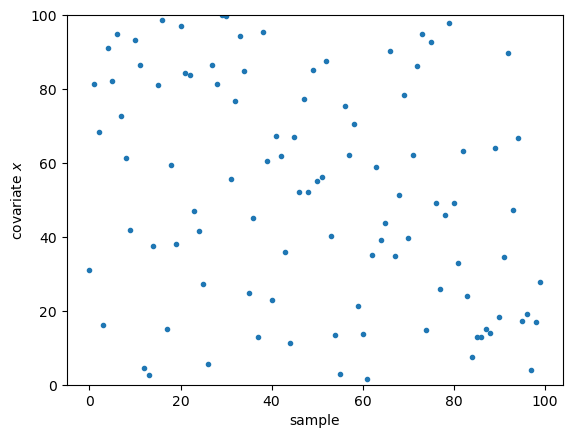

In [10]:
n_samples = 100
sample_skew = 1
x = generate_covar(n_samples, sample_skew)
ax = plot_covar(x)

### Generate target values

We could just use the ground truth function to generate the target values. However, to make things more interesting, we will add some noise to the target values.

We allow the noise to be a function of the covariate value $x$. When the noise is not constant over the range of a covariate, we say that the noise is **heteroscedastic**.

#### Generate noise

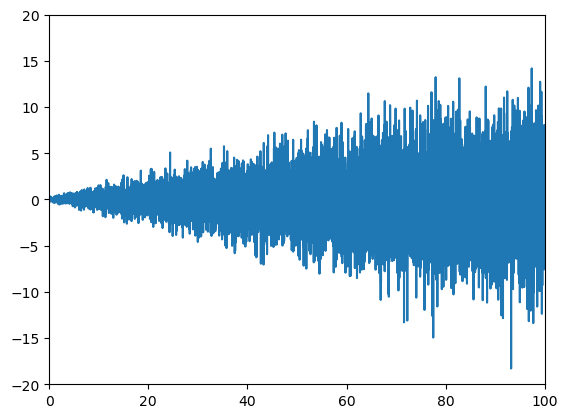

In [11]:
noise = generate_noise(x_axis, .1, 5)
_ = plt.plot(x_axis, noise)
plt.xlim(*xlim)
plt.ylim(*ylim)
plt.show()

In [12]:
# Again, you can play with the noise parameters to see how the noise affects the target values.
@interact(
    noise_level_left=FloatSlider(value=0, min=0, max=20, step=.5, description='noise_level_left'),
    noise_level_right=FloatSlider(value=5, min=0, max=20, step=.5, description='noise_level_right'),
) 
def plot_noise_interact(noise_level_left, noise_level_right):
  noise = generate_noise(x_axis, noise_level_left, noise_level_right)
  plt.plot(x_axis, noise)
  plt.xlim(*xlim)
  plt.ylim(*ylim)

interactive(children=(FloatSlider(value=0.0, description='noise_level_left', max=20.0, step=0.5), FloatSlider(…

#### Generate noisy target values

Finally, let's generate our noisy data by adding noise to the ground truth function. These are the data that we will use to train our model.

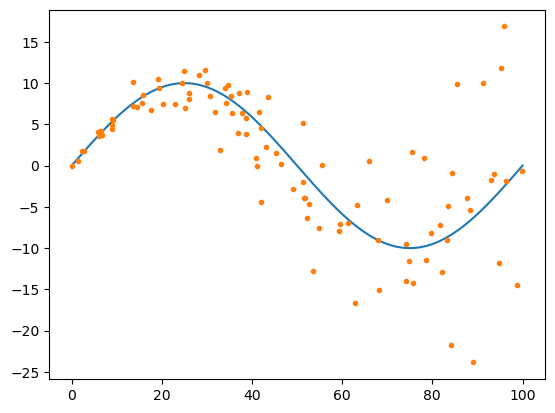

In [13]:

n_samples = 100
sample_skew = 1  
noise_level_left = 0
noise_level_right = 10
x, y = generate_data(n_samples, sample_skew, noise_level_left, noise_level_right)
plt.plot(x_axis, f(x_axis), '-')
plt.plot(x, y, '.')
plt.show()

### Train the Random Forest

Note, we don't tune the hyperparameters of the Random Forest here. We use the pre-defined values from the `Model` class.

Let's start with the simplest case: uniformly distributed covariate values and noise-free data.

In [14]:
sample_skew = 1
noise_level_left = 0
noise_level_right = 0
n_samples = 100
x, y = generate_data(n_samples, sample_skew, noise_level_left, noise_level_right)

Let's train our model. We will use a Random Forest with just 3 trees to see how a small ensemble behaves.

/Users/kmc3817/miniconda3/envs/h2smart/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


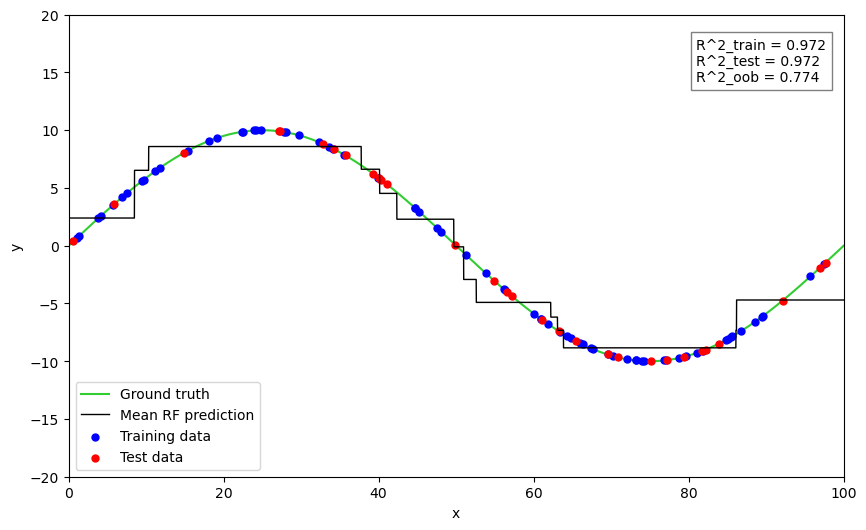

In [15]:
n_trees = 3
rf = Model(model_type='rf', n_trees=n_trees)
rf.split_and_train(x, y)
mean_predicted = rf.predict(x_axis)
fig, ax = plot_results(rf, mean_predicted)

This is the easy case: noise-free data. The model captures the ground truth function quite well, except for regions where data doesn't cover the covariate space. With real (noisy) data, the picture will be more interesting.

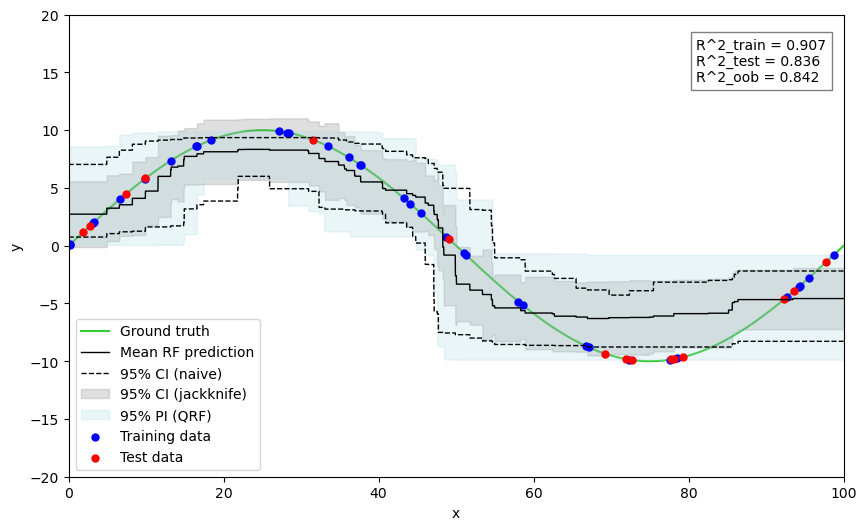

In [19]:
run_analysis(n_samples=50, sample_skew=1, noise_level_left=0, noise_level_right=0, n_trees=50)

Now let's add noise that increases with $x$ (heteroscedastic noise). Notice how the prediction interval from QRF widens where the noise is larger, while the naive CI does not adapt:

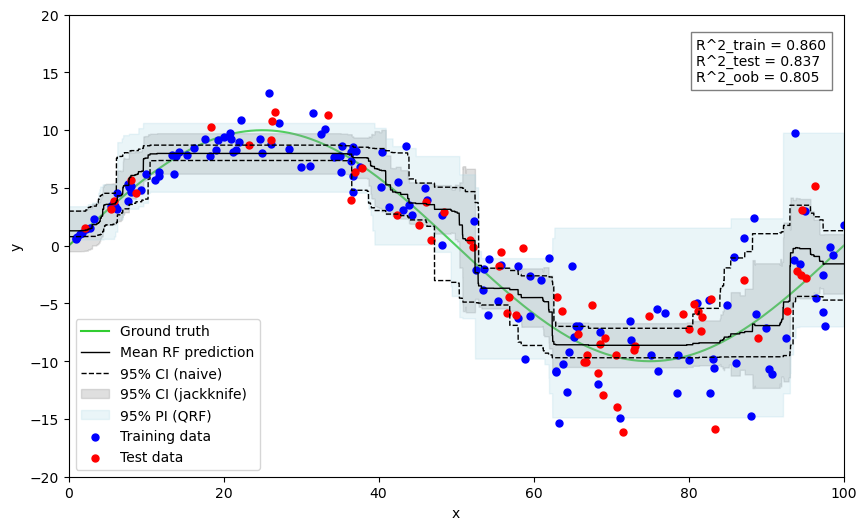

In [20]:
run_analysis(n_samples=200, sample_skew=1, noise_level_left=0, noise_level_right=5, n_trees=100)

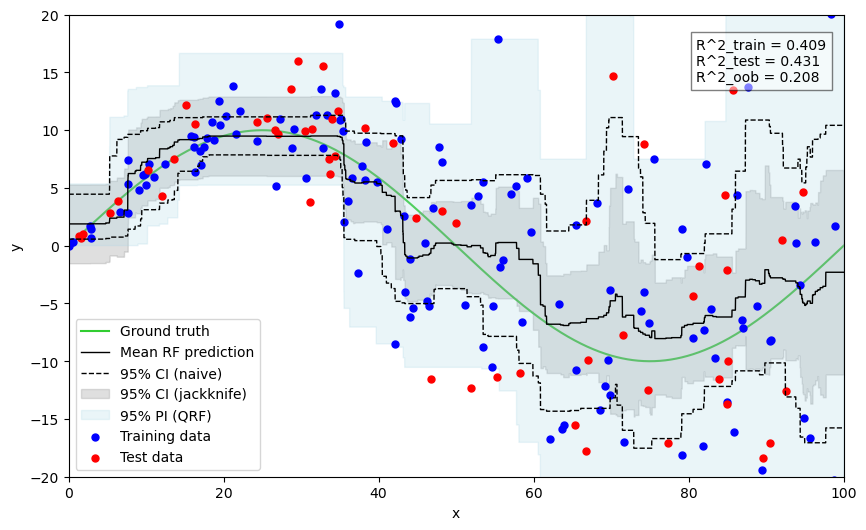

In [30]:
run_analysis(n_samples=200, sample_skew=1, noise_level_left=0, noise_level_right=15, n_trees=100)

### Exercise: play around with parameters

Use the interactive widget below to explore how the uncertainty estimates change as you vary the number of samples, sample skew, noise levels, and number of trees.

In [21]:
@interact(
    n_samples=IntSlider(value=500, min=10, max=1000, step=10, description='n_samples'),
    sample_skew=FloatSlider(value=1, min=0.01, max=10, step=0.01, description='sample_skew'),
    noise_level_left=FloatSlider(value=0, min=0, max=20, step=.5, description='noise_left'),
    noise_level_right=FloatSlider(value=5, min=0, max=20, step=.5, description='noise_right'),
    n_trees=IntSlider(value=100, min=10, max=1000, step=10, description='n_trees')
)
def plot_interact(n_samples, sample_skew, noise_level_left, noise_level_right, n_trees):
    run_analysis(n_samples, sample_skew, noise_level_left, noise_level_right, n_trees)

interactive(children=(IntSlider(value=500, description='n_samples', max=1000, min=10, step=10), FloatSlider(va…

### Practical takeaways

When you move from toy examples to real-world forests with 500+ trees, the "neighborhoods" become much more precise. Here is the essence of how to use these tools effectively:

**1. Know your tool**

- For the "Average" (Confidence Interval): Use `forestci`. This captures epistemic uncertainty. It tells you how much the mean prediction would wiggle if you resampled your data. It is narrow because it averages out the noise.
- For the "Reality" (Prediction Interval): Use `quantile-forest` (QRF). This captures aleatoric + epistemic uncertainty. It tells you where the next actual water sample is likely to land. It is wider because it respects the "beaver" and the "hungover lab assistant."

**2. The relationship**

A Prediction Interval (PI) is almost always wider than a Confidence Interval (CI).

- **PI width > CI width**: Normal. The model is acknowledging both its own limitations and the inherent messiness of nature.
- **PI width ≈ CI width**: This happens only if your data is "perfect" (zero noise), which almost never happens in environmental science.
- **PI width < CI width**: This is a red flag. It usually means your model is "lost" (extrapolating where it has no data) or your hyperparameters are poorly tuned, causing the interval estimators to break down.

**3. Practical goal**

Your goal is not to have the narrowest interval possible, but the most _honest_ one. A 95% PI is only "good" if 95% of your future water samples actually fall within it.

## Water Quality in Estonia

With real-world data we no longer have access to the true underlying function. Observed TN concentrations include measurement error, temporal variability, and other irreducible noise. We apply the same RF and QRF pipeline to real Estonian monitoring data from the Virro et al. (2022) study, using the same uncertainty tools (forestci CI, QRF PI) to quantify prediction uncertainty.

In [ ]:
gpkg_path = f"{data_dir}/agile2024_tn_mean_obs_sites.gpkg"
obs_data = gpd.read_file(gpkg_path)
eesti = gpd.read_file("data/estonia_outline.shp")

print(f"Loaded {len(obs_data)} sites (CRS: {obs_data.crs})")
print(f"Features: {obs_data.shape[1] - 4}, TN range: {obs_data['obs_value'].min():.2f} – {obs_data['obs_value'].max():.2f} mg/L")
obs_data.head(3)

Loaded 239 sites (CRS: EPSG:3301)
Features: 82, TN range: 0.48 – 11.93 mg/L


,site_code,obs_id,obs_value,arable_prop,arable_prop_buff_100,arable_prop_buff_1000,arable_prop_buff_500,area,awc1_min,awc1_max,...,tri_mean,tri_std,twi_min,twi_max,twi_mean,twi_std,urban_prop,water_prop,wetland_prop,geometry
0,SJA8127000,161,1.0288,0.086,0.175,0.092,0.124,151256900.0,0.178,0.212,...,0.119,0.176,2.206,14.725,9.732,1.706,0.006,0.005,0.129,POINT (696315 6546937)
1,SJA9900000,200,1.3402,0.182,0.170,0.178,0.190,807141375.0,0.173,0.215,...,0.100,0.191,1.725,15.356,9.827,1.375,0.026,0.008,0.087,POINT (669868 6591973)
2,SJA3956000,90,6.6156,0.536,0.340,0.520,0.464,422988125.0,0.169,0.207,...,0.112,0.150,1.869,15.563,9.910,1.513,0.049,0.003,0.006,POINT (636008 6603086)


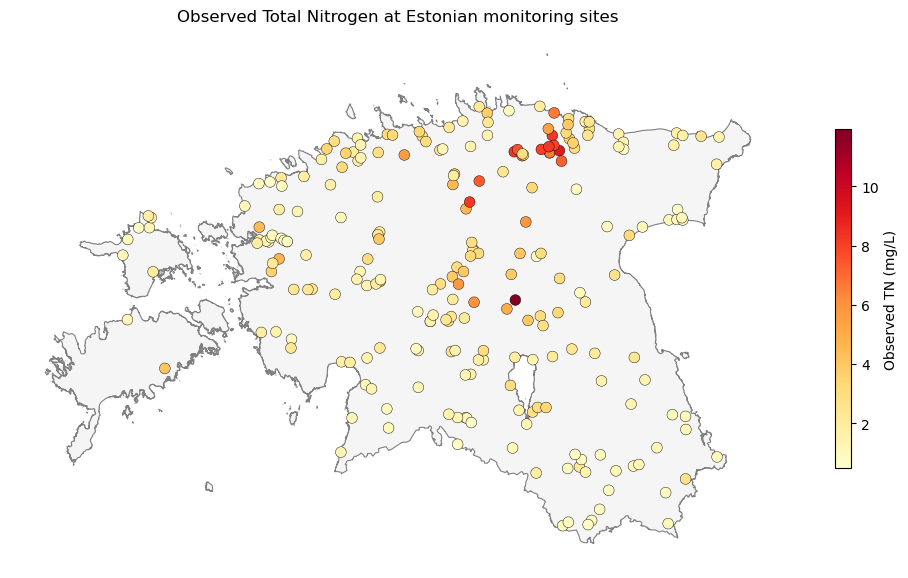

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
eesti.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.8)
obs_data.plot(
    ax=ax, column="obs_value", cmap="YlOrRd", markersize=60,
    edgecolor="k", linewidth=0.3, legend=True,
    legend_kwds={"label": "Observed TN (mg/L)", "shrink": 0.6},
)
ax.set_axis_off()
ax.set_title("Observed Total Nitrogen at Estonian monitoring sites", fontsize=12)
plt.tight_layout()

### Prepare features and target

We extract the numeric feature columns and the target variable (observed TN concentration). Then we split the data into training (70%) and test (30%) sets.

In [38]:
drop_cols = ["site_code", "obs_id", "obs_value", obs_data.geometry.name]
drop_cols = [c for c in drop_cols if c in obs_data.columns]
X = obs_data.drop(columns=drop_cols).select_dtypes(include=[np.number])
y = obs_data["obs_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
print(f"Training: {len(X_train)} sites, Test: {len(X_test)} sites")
print(f"Features: {X_train.shape[1]}")

Training: 167 sites, Test: 72 sites
Features: 82


### Hyperparameter tuning

We use `RandomizedSearchCV` to find good hyperparameters for the Random Forest. We tune four parameters: `n_estimators`, `max_depth`, `min_samples_leaf`, and `min_samples_split`. The best combination is selected based on 5-fold cross-validated MSE.

We then use the **same hyperparameters** for both the standard RF and the Quantile Regression Forest, so that the only difference between the two models is how they use their leaf contents (mean prediction vs. full distribution).

In [ ]:
# %%time
# Number of trees in random forest - test between 50 to 200 withtesting interval of 25
# step = 25
# n_estimators = list(np.arange(start=50, stop=200 + step, step=step))
# # Maximum number of levels in a tree - test between 5 and 20 withtesting interval of 5
# step = 5
# max_depth = list(np.arange(start=5, stop=20 + step, step=step))
# # Create dictionary from parameters
# param_distributions = {
#     "n_estimators": n_estimators,
#     "max_depth": max_depth
# }


# rf_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=SEED),
#     param_distributions=param_distributions,
#     n_iter=100,
#     scoring="neg_mean_squared_error",
#     cv=5,
#     random_state=SEED,
#     n_jobs=-1,
#     verbose=0,
# )
# rf_search.fit(X_train, y_train)

# best_params = rf_search.best_params_
# print("Best hyperparameters:")
# for k, v in best_params.items():
#     print(f"  {k}: {v}")
best_params = {'n_estimators': 125, 'max_depth': 10}

CPU times: user 39 μs, sys: 228 μs, total: 267 μs
Wall time: 1.74 ms


### Train the Random Forest

In [45]:
rf_params = {**best_params, "bootstrap": True, "oob_score": True, "random_state": SEED}
rf_real = RandomForestRegressor(**rf_params)
rf_real.fit(X_train, y_train)

y_pred_train = rf_real.predict(X_train)
y_pred_test = rf_real.predict(X_test)

print(f"R² train: {r2_score(y_train, y_pred_train):.3f}")
print(f"R² test:  {r2_score(y_test, y_pred_test):.3f}")
print(f"R² OOB:   {rf_real.oob_score_:.3f}")
print(f"RMSE test: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f} mg/L")

R² train: 0.937
R² test:  0.621
R² OOB:   0.530
RMSE test: 1.200 mg/L


### Train the Quantile Regression Forest

We use the same hyperparameters so the comparison between CI and PI is clean.

In [46]:
qrf_params = {**best_params, "bootstrap": True, "random_state": SEED}
qrf_real = RandomForestQuantileRegressor(**qrf_params)
qrf_real.fit(X_train, y_train)

print(f"QRF R² test: {r2_score(y_test, qrf_real.predict(X_test)):.3f}")

QRF R² test: 0.677


### Compute uncertainty intervals on the test set

- **Confidence Interval (CI)** via `forestci` — jackknife estimate of the mean prediction uncertainty (epistemic)
- **Prediction Interval (PI)** via QRF — 2.5th and 97.5th percentiles of the conditional distribution (epistemic + aleatoric)

In [47]:
# CI via forestci (jackknife)
variance_test = fci.random_forest_error(rf_real, X_train.values, X_test.values)
std_test = np.sqrt(np.clip(variance_test, 0, None))
ci_lo = y_pred_test - 1.96 * std_test
ci_hi = y_pred_test + 1.96 * std_test

# PI via QRF
pi_pred = qrf_real.predict(X_test, quantiles=[0.025, 0.5, 0.975])
pi_lo = pi_pred[:, 0]
pi_median = pi_pred[:, 1]
pi_hi = pi_pred[:, 2]

print(f"Median CI width: {np.median(ci_hi - ci_lo):.2f} mg/L")
print(f"Median PI width: {np.median(pi_hi - pi_lo):.2f} mg/L")

Median CI width: 2.78 mg/L
Median PI width: 3.60 mg/L


### Visualise uncertainty: non-spatial

Two views of the test-set predictions and their uncertainty bands:

- **(a)** Test points sorted by predicted value, with CI and PI bands
- **(b)** Observed vs. predicted scatter with interval error bars

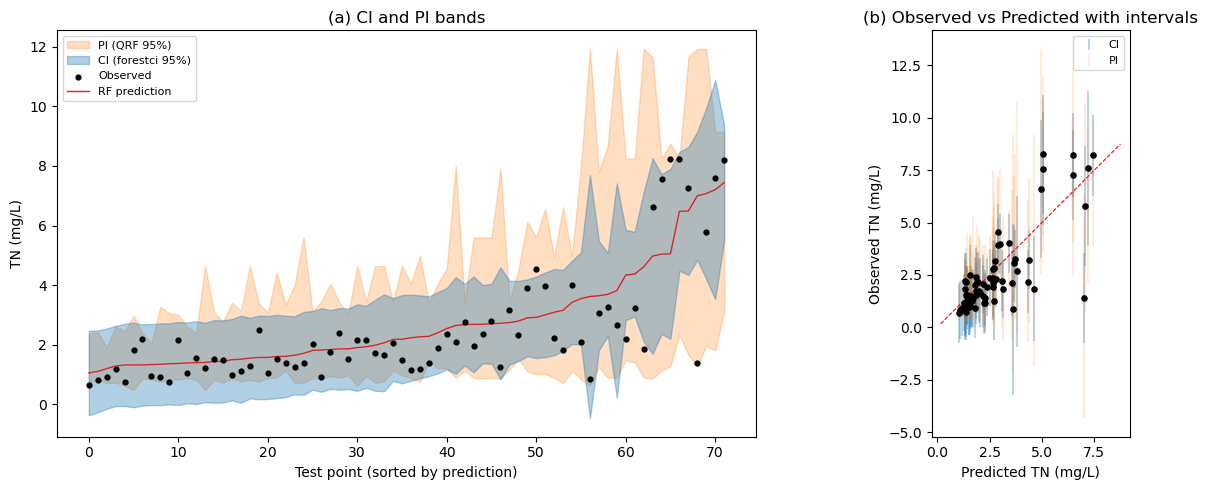

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sort_idx = np.argsort(y_pred_test)
x_axis_sorted = np.arange(len(sort_idx))

# (a) Sorted bands
ax = axes[0]
ax.fill_between(x_axis_sorted, pi_lo[sort_idx], pi_hi[sort_idx],
                alpha=0.25, color="C1", label="PI (QRF 95%)")
ax.fill_between(x_axis_sorted, ci_lo[sort_idx], ci_hi[sort_idx],
                alpha=0.35, color="C0", label="CI (forestci 95%)")
ax.scatter(x_axis_sorted, y_test.values[sort_idx], s=12, color="k", zorder=3, label="Observed")
ax.plot(x_axis_sorted, y_pred_test[sort_idx], color="C3", lw=1, label="RF prediction")
ax.set(xlabel="Test point (sorted by prediction)", ylabel="TN (mg/L)",
       title="(a) CI and PI bands")
ax.legend(fontsize=8)

# (b) Obs vs Pred with error bars
ax = axes[1]
ax.errorbar(y_pred_test, y_test, yerr=[y_pred_test - ci_lo, ci_hi - y_pred_test],
            fmt="none", ecolor="C0", alpha=0.3, label="CI")
ax.errorbar(y_pred_test, y_test, yerr=[y_pred_test - pi_lo, pi_hi - y_pred_test],
            fmt="none", ecolor="C1", alpha=0.15, label="PI")
ax.scatter(y_pred_test, y_test, s=14, color="k", zorder=3)
mn = min(y_test.min(), y_pred_test.min()) - 0.5
mx = max(y_test.max(), y_pred_test.max()) + 0.5
ax.plot([mn, mx], [mn, mx], "r--", lw=0.8)
ax.set_aspect("equal")
ax.set(xlabel="Predicted TN (mg/L)", ylabel="Observed TN (mg/L)",
       title="(b) Observed vs Predicted with intervals")
ax.legend(fontsize=8)

plt.tight_layout()

### Compute predictions and uncertainty for all sites

For the spatial maps, we need predictions and intervals at all 239 monitoring locations (not just the test set).

In [49]:
y_pred_all = rf_real.predict(X)

# CI for all sites
variance_all = fci.random_forest_error(rf_real, X_train.values, X.values)
std_all = np.sqrt(np.clip(variance_all, 0, None))
ci_lo_all = y_pred_all - 1.96 * std_all
ci_hi_all = y_pred_all + 1.96 * std_all

# PI for all sites
pi_pred_all = qrf_real.predict(X, quantiles=[0.025, 0.5, 0.975])
pi_lo_all = pi_pred_all[:, 0]
pi_hi_all = pi_pred_all[:, 2]

# Attach to GeoDataFrame
obs_data["pred_TN"] = y_pred_all
obs_data["ci_width"] = ci_hi_all - ci_lo_all
obs_data["pi_width"] = pi_hi_all - pi_lo_all
obs_data["ci_lo"] = ci_lo_all
obs_data["ci_hi"] = ci_hi_all
obs_data["pi_lo"] = pi_lo_all
obs_data["pi_hi"] = pi_hi_all

print(f"Predictions and intervals computed for {len(obs_data)} sites")
print(f"Median PI width: {obs_data['pi_width'].median():.2f} mg/L")
print(f"Median CI width: {obs_data['ci_width'].median():.2f} mg/L")

Predictions and intervals computed for 239 sites
Median PI width: 2.53 mg/L
Median CI width: 2.36 mg/L


### Visualise uncertainty: spatial

We now map the predictions and their uncertainty across Estonia using three complementary approaches:

1. **Interval width as colour** — separate maps for predictions and uncertainty
2. **Transparency** — uncertain predictions fade away
3. **Point size** — more certain predictions are larger

#### (1) Predictions and interval width side by side

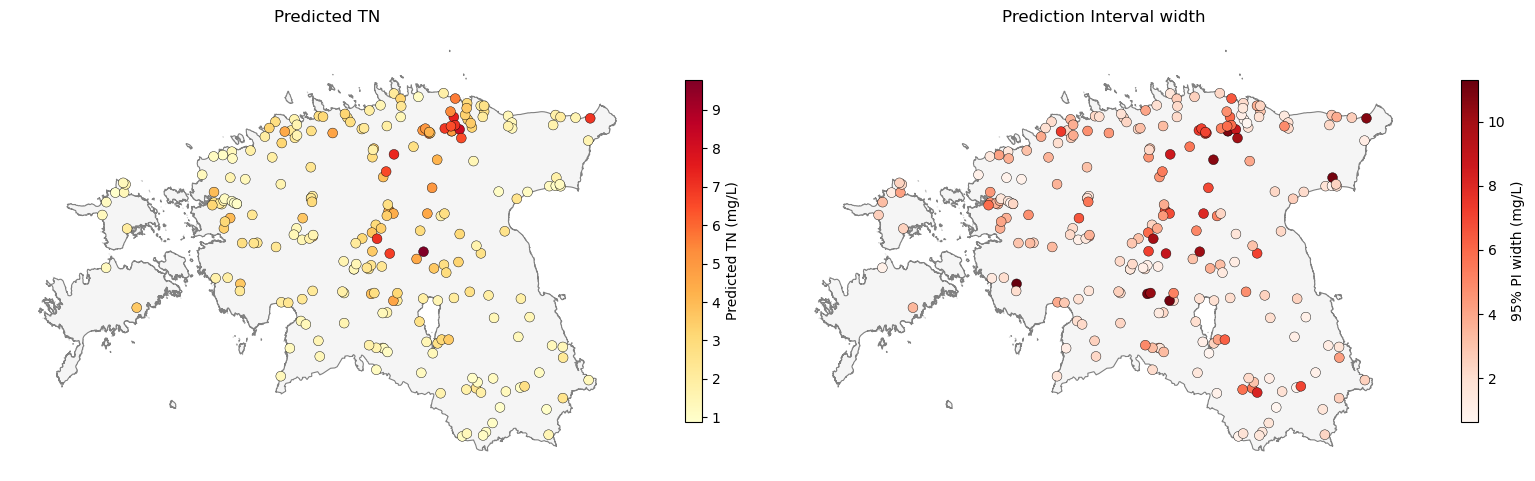

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: predicted TN
ax = axes[0]
eesti.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.8)
obs_data.plot(
    ax=ax, column="pred_TN", cmap="YlOrRd", markersize=50,
    edgecolor="k", linewidth=0.3, legend=True,
    legend_kwds={"label": "Predicted TN (mg/L)", "shrink": 0.6},
)
ax.set_axis_off()
ax.set_title("Predicted TN")

# Right: PI width
ax = axes[1]
eesti.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.8)
obs_data.plot(
    ax=ax, column="pi_width", cmap="Reds", markersize=50,
    edgecolor="k", linewidth=0.3, legend=True,
    legend_kwds={"label": "95% PI width (mg/L)", "shrink": 0.6},
)
ax.set_axis_off()
ax.set_title("Prediction Interval width")

plt.tight_layout()

#### (2) Predictions with uncertainty as transparency

Points with wider prediction intervals become more transparent. This lets trustworthy predictions stand out while uncertain ones fade into the background.

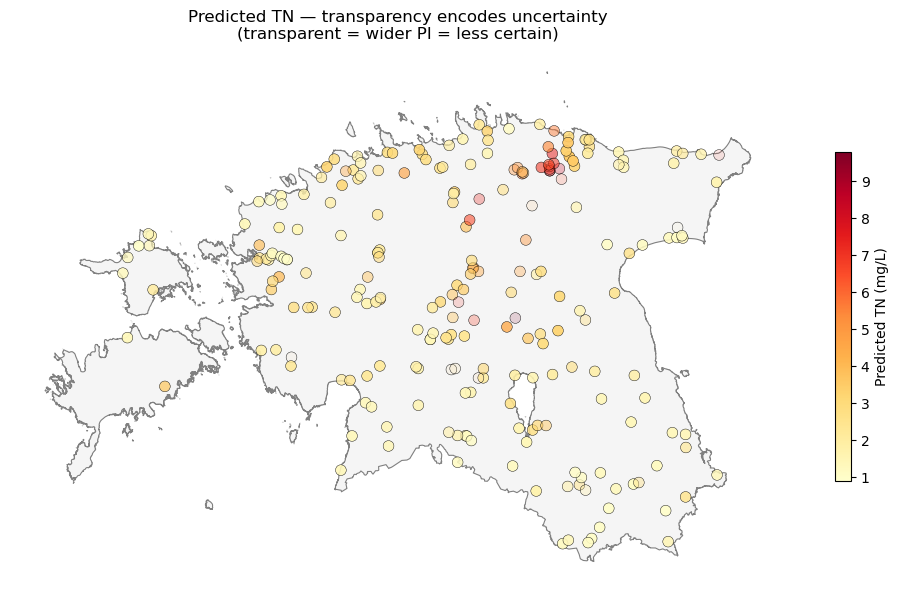

In [54]:
from matplotlib.colors import Normalize


pi_w = obs_data["pi_width"].values
alpha_min, alpha_max = 0.05, 1.0
alphas = alpha_max - (pi_w - pi_w.min()) / (pi_w.max() - pi_w.min()) * (alpha_max - alpha_min)

# Build RGBA array from colormap
cmap = plt.cm.YlOrRd
norm = Normalize(vmin=obs_data["pred_TN"].min(), vmax=obs_data["pred_TN"].max())
colors = cmap(norm(obs_data["pred_TN"].values))
colors[:, 3] = alphas

fig, ax = plt.subplots(figsize=(10, 6))
eesti.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.8)
ax.scatter(
    obs_data.geometry.x, obs_data.geometry.y,
    c=colors, s=60, edgecolor="k", linewidth=0.3, zorder=3,
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, label="Predicted TN (mg/L)")

ax.set_axis_off()
ax.set_title("Predicted TN — transparency encodes uncertainty\n(transparent = wider PI = less certain)")
plt.tight_layout()

This visualisation method doesn't work very well currently. 

**Task**
Make this map more informative! Perhaps consider using just a few discrete ranges of alpha.

#### (3) Predictions with uncertainty as point size

Bigger points = more certain predictions (narrower PI). This draws the eye to the locations where the model is most reliable.

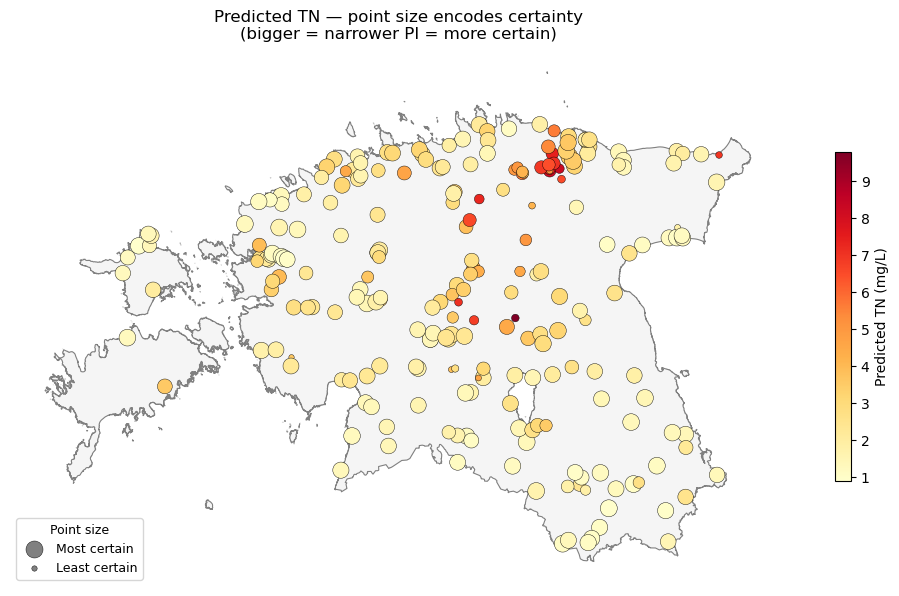

In [53]:
size_min, size_max = 15, 150
pi_w = obs_data["pi_width"].values
certainty = 1 - (pi_w - pi_w.min()) / (pi_w.max() - pi_w.min())
sizes = size_min + certainty * (size_max - size_min)

fig, ax = plt.subplots(figsize=(10, 6))
eesti.plot(ax=ax, color="whitesmoke", edgecolor="grey", linewidth=0.8)
sc = ax.scatter(
    obs_data.geometry.x, obs_data.geometry.y,
    c=obs_data["pred_TN"], cmap="YlOrRd", s=sizes,
    edgecolor="k", linewidth=0.3, zorder=3,
)
plt.colorbar(sc, ax=ax, shrink=0.6, label="Predicted TN (mg/L)")

# Size legend
for label, cert in [("Most certain", 1.0), ("Least certain", 0.0)]:
    sz = size_min + cert * (size_max - size_min)
    ax.scatter([], [], c="grey", s=sz, edgecolor="k", linewidth=0.3, label=label)
ax.legend(loc="lower left", fontsize=9, title="Point size", title_fontsize=9)

ax.set_axis_off()
ax.set_title("Predicted TN — point size encodes certainty\n(bigger = narrower PI = more certain)")
plt.tight_layout()

# This is the END.